<h1 align="center"> Projeto 4 </h1>
<center><h3> Álgebra Linear Numérica </h3></center>
<p align="center"> Participantes: Pedro Ricardo Alves e Elainne Rohs </p>

### Questão 2. Forma de Hessemberg

In [13]:
using LinearAlgebra
using LaTeXStrings
using Plots

In [2]:
function find_beta(x)
    if x[1] < 0
        beta = 1/(norm(x) * (norm(x) - x[1]))
    else
        beta = (norm(x) + x[1])/(norm(x) * norm(x[2:end])^2)
    end
    return beta
end

find_beta (generic function with 1 method)

#### Letra a)

In [3]:
function apply_reflector(v, beta, b)
    newb = copy(b)
    idx = length(b) -  length(v) + 1
    newb[idx:end] =  (b[idx:end] - beta * dot(v, b[idx:end]) * v)
    return newb
end

apply_reflector (generic function with 1 method)

#### Letra b)

##### Verificações:

* Aplicar Q em x tem que preservar sua norma

In [4]:
lengths = [100,500,1000]
for i in lengths
    x = randn(i)
    v = copy(x)
    v[1] = v[1] - norm(x)
    beta = find_beta(x)
    Qx = apply_reflector(v, beta, x)
    

    println("Norma Qx: ", norm(Qx))
    println("Norma x: ", norm(x))
    println("Diferença entre as normas: ", norm(Qx) - norm(x), "\n")

    plus = 100
    y = randn(i + plus)
    yc = y[(plus + 1):end]
    v = copy(yc)

    v[1] = v[1] - norm(yc)
    beta = find_beta(yc)

    Qy = apply_reflector(v, beta, y)

    println("Norma Qy: ", norm(Qy))
    println("Norma y: ", norm(y))
    println("Diferença entre as normas(CASO MAIOR): ", norm(Qy) - norm(y), "\n")
end

Norma Qx: 9.49730014514628
Norma x: 9.49730014514628
Diferença entre as normas: 0.0

Norma Qy: 14.336102734219391
Norma y: 14.33610273421939
Diferença entre as normas(CASO MAIOR): 1.7763568394002505e-15

Norma Qx: 21.858276341127446
Norma x: 21.858276341127446
Diferença entre as normas: 0.0

Norma Qy: 23.275783729159638
Norma y: 23.275783729159635
Diferença entre as normas(CASO MAIOR): 3.552713678800501e-15

Norma Qx: 30.83430345501173
Norma x: 30.83430345501173
Diferença entre as normas: 0.0

Norma Qy: 32.832620321440054
Norma y: 32.83262032144007
Diferença entre as normas(CASO MAIOR): -1.4210854715202004e-14



* Aplicar a mesma Q duas vezes volta pro original:

In [5]:
lengths = [10,50,100,500,1000]
for i in lengths
    x = randn(i)
    v = copy(x)
    v[1] = v[1] - norm(x)
    beta = find_beta(x)

    Qx = apply_reflector(v, beta, x)
    QQx = apply_reflector(v, beta, Qx)

    println("Aproximação de QQx com x: ", QQx ≈ x)
    println("Norma da diferença: ", norm(QQx - x))

    plus = 100
    y = randn(i + plus)
    yc = y[(plus + 1):end]
    v = copy(yc)

    v[1] = v[1] - norm(yc)
    beta = find_beta(yc)

    Qy = apply_reflector(v, beta, y)
    QQy = apply_reflector(v, beta, Qy)

    println("Aproximação de QQy com y: ", QQy ≈ y)
    println("Norma da diferença: ", norm(QQy - y), "\n")
end

Aproximação de QQx com x: true
Norma da diferença: 2.4201226626195277e-15
Aproximação de QQy com y: true
Norma da diferença: 7.468261590855957e-16

Aproximação de QQx com x: true
Norma da diferença: 2.220446049250313e-16
Aproximação de QQy com y: true
Norma da diferença: 2.220446049250313e-16

Aproximação de QQx com x: true
Norma da diferença: 5.014444382424447e-15
Aproximação de QQy com y: true
Norma da diferença: 3.4977085595323546e-15

Aproximação de QQx com x: true
Norma da diferença: 1.086312111440466e-14
Aproximação de QQy com y: true
Norma da diferença: 1.0548494745050844e-14

Aproximação de QQx com x: true
Norma da diferença: 1.7383793571903964e-14
Aproximação de QQy com y: true
Norma da diferença: 9.706760740468602e-15



* As entradas abaixo da primeira entrada do vetor que será refletido são todas 0:

In [ ]:
lengths = [10,50,100,500,1000]

for i in lengths
    x = randn(i)
    v = copy(x)
    v[1] = v[1] - norm(x)
    beta = find_beta(x)

    Qx = apply_reflector(v, beta, x)

    println("Norma dos zeros abaixo da entrada desejada: ", norm(Qx[2:end]))

    plus = 100
    y = randn(i + plus)
    yc = y[(plus + 1):end]
    v = copy(yc)

    v[1] = v[1] - norm(yc)
    beta = find_beta(yc)

    Qy = apply_reflector(v, beta, y)
    println("Norma dos zeros abaixo da entrada desejada(CASO MAIOR): ", norm(Qy[(plus + 2):end]), "\n")
end

Norma dos zeros abaixo da entrada desejada: 3.8081823067227083e-16
Norma dos zeros abaixo da entrada desejada(CASO MAIOR): 7.196573046735734e-16

Norma dos zeros abaixo da entrada desejada: 0.0
Norma dos zeros abaixo da entrada desejada(CASO MAIOR): 1.4142454989598061e-15

Norma dos zeros abaixo da entrada desejada: 1.8974203645000124e-15
Norma dos zeros abaixo da entrada desejada(CASO MAIOR): 0.0

Norma dos zeros abaixo da entrada desejada: 4.876340090852715e-15
Norma dos zeros abaixo da entrada desejada(CASO MAIOR): 3.5031142845806655e-15

Norma dos zeros abaixo da entrada desejada: 0.0
Norma dos zeros abaixo da entrada desejada(CASO MAIOR): 1.3457143986429581e-14



* Plotagem do vetor original e do vetor refletido

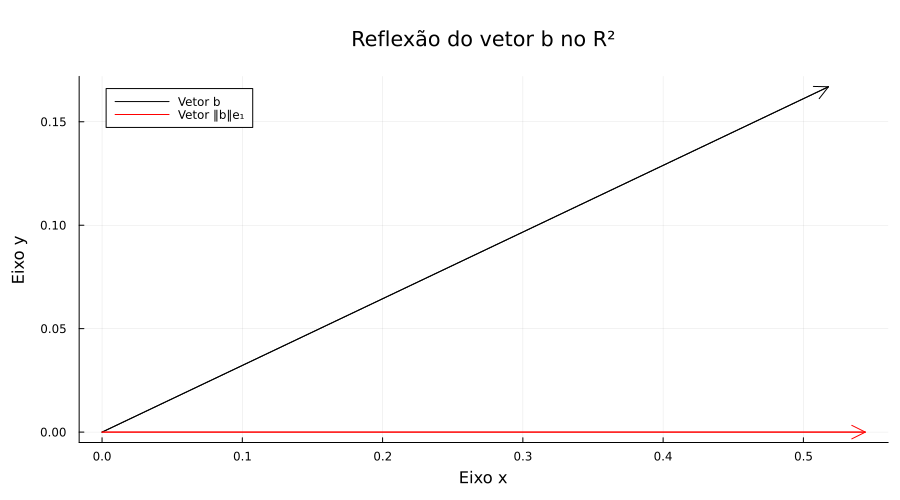

In [131]:
b = randn(2)
x = [b[1]]
y = [b[2]]

v = copy(b)
v[1] = v[1] - norm(b)
beta = find_beta(b)
Qb = apply_reflector(v, beta, b)

push!(x, Qb[1])
push!(y, Qb[2])

plot([0, x[1]], [0, y[1]], arrow=true, color=:black, label="Vetor b", size=(900,500), xlabel="Eixo x", ylabel="Eixo y", title="\nReflexão do vetor b no R²", top_margin=10Plots.mm, left_margin=5Plots.mm, bottom_margin=5Plots.mm)
plot!([0, x[2]], [0, y[2]], arrow=true, color=:red, label="Vetor ‖b‖e₁")

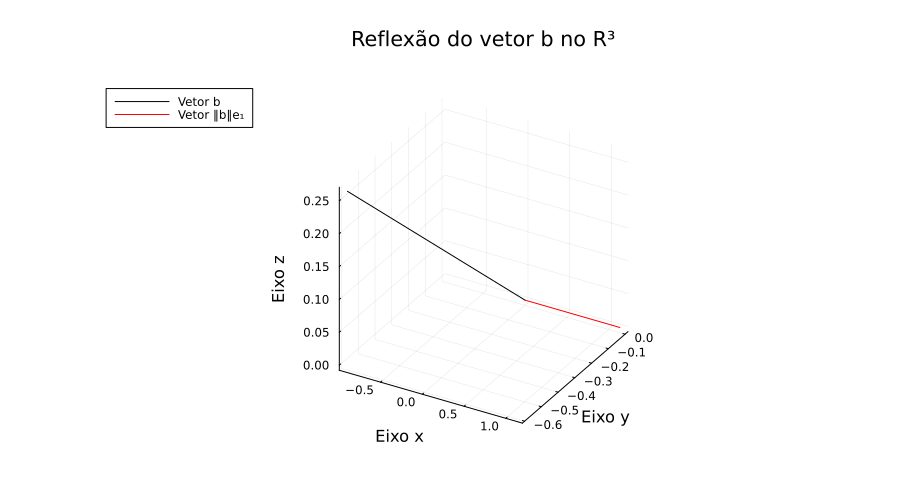

In [147]:
b = randn(3)
v = copy(b)
v[1] = v[1] - norm(b)
beta = find_beta(b)
Qb = apply_reflector(v, beta, b)

plot([0, b[1]], [0, b[2]], [0, b[3]], arrow=true, color=:black, label="Vetor b", size=(900,500), xlabel="Eixo x", ylabel="Eixo y", zlabel="Eixo z", title="\nReflexão do vetor b no R³", top_margin=10Plots.mm, left_margin=5Plots.mm, bottom_margin=5Plots.mm)
plot!([0, Qb[1]], [0, Qb[2]], [0, Qb[3]], arrow=true, color=:red, label="Vetor ‖b‖e₁")


##### Justificativa de complexidade da função:

Note que a função é $O(n)$ em ambos os casos, já que a cópia é $O(n)$, enquanto o produto escalar e as operações elemento a elemento são $O(length(v)) \leq O(n)$; ou seja, tanto para o caso em que o vetor de entrada é maior que o refeletor quanto para o caso em que o vetor de entrada é do mesmo tamanho do refletor, o processo é análogo devido ao copy, ou seja, resulta em $O(n)$.

#### Letra c)

In [7]:
function apply_reflector(v, beta, A)
    idx = size(A, 1) - length(v) + 1
    newA = copy(A)
    newA[idx:end, :] = A[idx:end, :] - beta * v * (v' * A[idx:end, :])
    return newA
end

apply_reflector (generic function with 1 method)

#### Letra d)

In [8]:
function rev_apply_reflector(v, beta, A)
    idx = size(A, 2) - length(v) + 1
    newA = copy(A)
    newA[:, idx:end] = A[:, idx:end] - beta * (A[:, idx:end] * v) * v'
    return newA
end

rev_apply_reflector (generic function with 1 method)

#### Letra e)

In [9]:
function to_hessemberg(A)
    reflectors = []
    H = copy(A)
    n = size(A, 1)
    Q = Matrix{Float64}(I, n, n)
    
    for k in 1:(size(A, 1) - 2)
        x = H[(k + 1):end, k]
        v = copy(x)
        v[1] = v[1] - norm(x)
        beta = find_beta(x)
        
        F = I - beta * v * v'
        Qaux = Matrix{Float64}(I, n, n)
        Qaux[k+1:end, k+1:end] = F
        Q = Q * Qaux'

        H[(k + 1):end, k:end] = apply_reflector(v, beta, H[(k + 1):end, k:end])
        H[1:end, (k + 1):end] = rev_apply_reflector(v, beta, H[1:end, (k + 1):end])
        push!(reflectors, (v, beta))
    end
    return reflectors, H, Q
end

to_hessemberg (generic function with 1 method)

#### Letra f)

In [11]:
lengths = [2, 10, 100]

# Matrizes simétricas:
println("Matrizes simétricas: ---------------------------------- \n")
println("Valor de ‖A - QHQ*‖:")
for l in lengths
    A = randn(l,l)
    B = A' * A
    refs, H, Q = to_hessemberg(B)
    println("tamanho $(l)x$l: ", norm(B - (Q * H * Q')))
end
println("\nValor de ∥Q*Q − I∥:")
for l in lengths
    A = randn(l,l)
    B = A' * A
    refs, H, Q = to_hessemberg(B)
    println("tamanho $(l)x$l: ", norm(Q' * Q - I))
end

# Matrizes não simétricas:
println("\nMatrizes não simétricas: ------------------------------ \n")
println("Valor de ‖A - QHQ*‖:")
for l in lengths
    A = randn(l,l)
    refs, H, Q = to_hessemberg(A)
    println("tamanho $(l)x$l: ", norm(A - (Q * H * Q')))
end
println("\nValor de ∥Q*Q − I∥:")
for l in lengths
    A = randn(l,l)
    refs, H, Q = to_hessemberg(A)
    println("tamanho $(l)x$l: ", norm(Q' * Q - I))
end

Matrizes simétricas: ---------------------------------- 

Valor de ‖A - QHQ*‖:
tamanho 2x2: 0.0
tamanho 10x10: 3.8097188928707886e-14
tamanho 100x100: 3.004158486637222e-12

Valor de ∥Q*Q − I∥:
tamanho 2x2: 0.0
tamanho 10x10: 1.2596516135573968e-15
tamanho 100x100: 2.7881018472131302e-14

Matrizes não simétricas: ------------------------------ 

Valor de ‖A - QHQ*‖:
tamanho 2x2: 0.0
tamanho 10x10: 6.182290652392426e-15
tamanho 100x100: 2.5605329557118255e-13

Valor de ∥Q*Q − I∥:
tamanho 2x2: 0.0
tamanho 10x10: 1.8137580231980832e-15
tamanho 100x100: 2.8476163598322035e-14
